In [2]:
pip install pymongo

   ---------------------------------------- 0.0/962.6 kB ? eta -:--:--
   ------------------------------- ------- 786.4/962.6 kB 13.1 MB/s eta 0:00:01
   ---------------------------------------- 962.6/962.6 kB 10.9 MB/s  0:00:00

   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [d

In [9]:
from pymongo import MongoClient

# Requires the PyMongo package.
# https://api.mongodb.com/python/current

client = MongoClient('mongodb://localhost:27017/')
filter={
    'year': {
        '$gte': 1960, 
        '$lte': 2015
    }, 
    'actors': 'Harrison Ford'
}
project={
    '_id': 0, 
    'title': 1, 
    'year': 1, 
    'imdb.rating': 1
}
sort=list({
    'year': -1, 
    'imdb.rating': -1
}.items())

result = client['6606405']['movie'].find(
  filter=filter,
  projection=project,
  sort=sort
)


for x in result:
    print(x)

{'title': 'Star Wars: Episode VI - Return of the Jedi', 'year': 1983, 'imdb': {'rating': 8.4}}
{'title': 'Raiders of the Lost Ark', 'year': 1981, 'imdb': {'rating': 8.5}}
{'title': 'Star Wars: Episode V - The Empire Strikes Back', 'year': 1980, 'imdb': {'rating': 8.8}}
{'title': 'Star Wars: Episode IV - A New Hope', 'year': 1977, 'imdb': {'rating': 8.7}}


<Axes: >

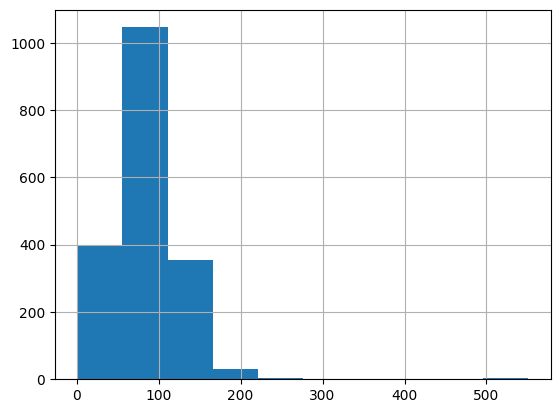

In [12]:
import pandas as pd

filter = {}
result = client['6606405']['movie'].find(
  filter = filter,
)

df = pd.DataFrame(list(result))
df.drop("_id", axis = 1, inplace = True)
df["runtime"].hist()

In [16]:
from pymongo import MongoClient
import pandas as pd
import json

client = MongoClient('mongodb://localhost:27017/')
mydb = client["6606405"]
mycol = mydb["chronic"]

df = pd.read_csv("./assets/chronic_2016_90_all.csv", low_memory=False)
data_json = json.loads(df.to_json(orient="records"))
result = mycol.insert_many(data_json)

len(result.inserted_ids)

C:\Users\nemoz\AppData\Local\Temp\ipykernel_24132\1176735459.py:9: DtypeWarning: Columns (1,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./assets/chronic_2016_90_all.csv")


642476